In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
## Step 1: Load and Preprocess Data
# Load training and test datasets
df_train = pd.read_csv('trainset.csv')
df_test = pd.read_csv('testset.csv')

In [3]:
# Use closing prices
train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [4]:
# Normalize the data based on training set only
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [5]:
# Create sequences
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_length = 60
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)


In [6]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [7]:
# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [8]:
# Create dataset and dataloader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [9]:
## Step 2: Define RNN Model
class RNNModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=50,
                 num_layers=2, output_size=1):
        super(RNNModel, self).__init__()

        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):
        out, hidden = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)

        return out





In [10]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [11]:
!pip install torchinfo


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from torchinfo import summary

# input_size = (batch_size, seq_len, input_size)
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 50]              7,750
├─Linear: 1-2                            [64, 1]                   51
Total params: 7,801
Trainable params: 7,801
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 29.76
Input size (MB): 0.02
Forward/backward pass size (MB): 1.54
Params size (MB): 0.03
Estimated Total Size (MB): 1.58

In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
## Step 3: Train the Model
num_epochs = 50

train_losses = []


for epoch in range(num_epochs):

    # Training mode
    model.train()

    running_loss = 0.0

    for batch_x, batch_y in train_loader:

        # Move data to GPU/CPU
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_x)

        # Calculate loss
        loss = criterion(outputs, batch_y)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        running_loss += loss.item()

    # Average loss
    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.6f}"
    )
# Write your code here


Epoch [1/50], Loss: 0.062599
Epoch [2/50], Loss: 0.019281
Epoch [3/50], Loss: 0.002001
Epoch [4/50], Loss: 0.000760
Epoch [5/50], Loss: 0.000446
Epoch [6/50], Loss: 0.000409
Epoch [7/50], Loss: 0.000408
Epoch [8/50], Loss: 0.000432
Epoch [9/50], Loss: 0.000369
Epoch [10/50], Loss: 0.000373
Epoch [11/50], Loss: 0.000407
Epoch [12/50], Loss: 0.000351
Epoch [13/50], Loss: 0.000365
Epoch [14/50], Loss: 0.000348
Epoch [15/50], Loss: 0.000323
Epoch [16/50], Loss: 0.000316
Epoch [17/50], Loss: 0.000414
Epoch [18/50], Loss: 0.000408
Epoch [19/50], Loss: 0.000302
Epoch [20/50], Loss: 0.000303
Epoch [21/50], Loss: 0.000280
Epoch [22/50], Loss: 0.000286
Epoch [23/50], Loss: 0.000270
Epoch [24/50], Loss: 0.000266
Epoch [25/50], Loss: 0.000264
Epoch [26/50], Loss: 0.000274
Epoch [27/50], Loss: 0.000265
Epoch [28/50], Loss: 0.000301
Epoch [29/50], Loss: 0.000282
Epoch [30/50], Loss: 0.000273
Epoch [31/50], Loss: 0.000268
Epoch [32/50], Loss: 0.000286
Epoch [33/50], Loss: 0.000274
Epoch [34/50], Loss

Name: Santhosh V
Register Number: 212224230251


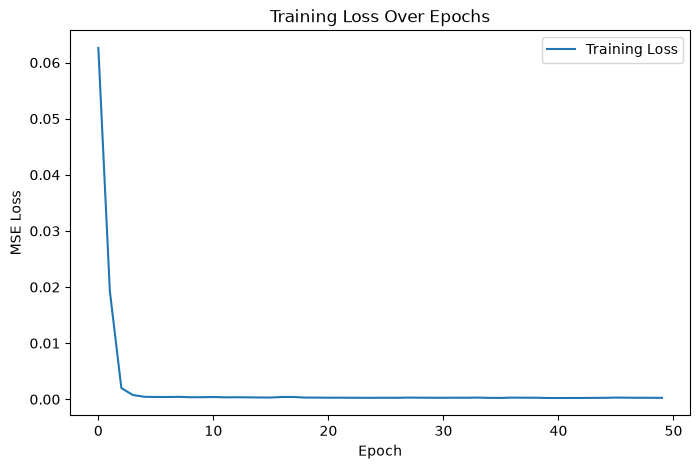

In [17]:
# Plot training loss
print('Name: Santhosh V')
print('Register Number: 212224230251')

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label='Training Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()


Name: Santhosh V
Register Number: 212224230251


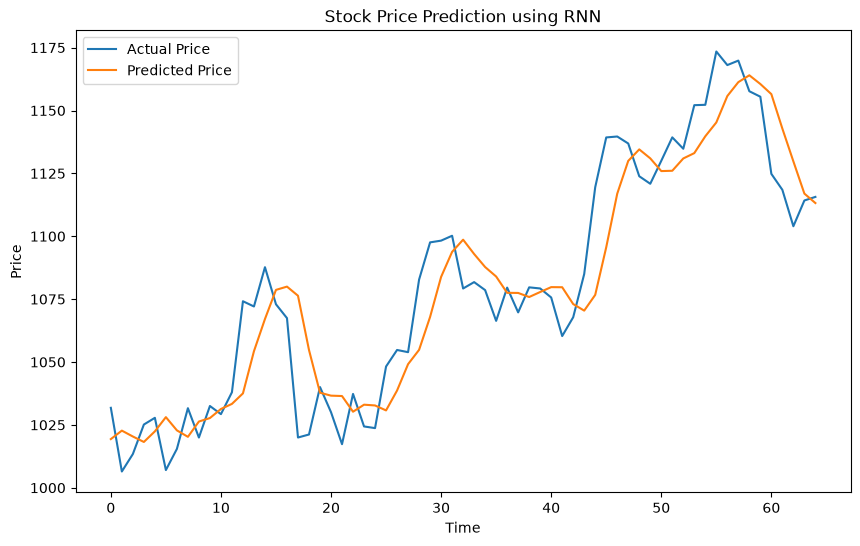

Predicted Price: [1113.2037]
Actual Price: [1115.65]


In [18]:
## Step 4: Make Predictions on Test Set
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()

# Inverse transform the predictions and actual values
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

# Plot the predictions vs actual prices
print('Name: Santhosh V')
print('Register Number: 212224230251')
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()
print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')